# CSCA 5642 Final Project

## Introduction
In this project, we will train a deep learning model to extract sentiment from [resumes](https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset/data) to predict their appropriate job categories. Recruiters and hiring managers get 1000s of resumes for a single position, especially for large companies. The sheer volume makes it impossible for a single recruiter or even a team to evaluate every application fairly within the hiring period. In this project, we aim to build a model to categorize resumes into the appropriate roles and generate a summary describing the candidate. The purpose of this is to prepare a concise summary to expedite the resume review process.

## Contents
* Exploratory Data Analysis
* Data Processing
* Model Training
* Resume Categorization and Summary

In [1]:
import os
import random
from pathlib import Path
import shutil
import fitz
import re
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ExponentialLR
from torch.nn import CrossEntropyLoss
from transformers import BertModel, BertTokenizer, BertForSequenceClassification, pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments
from datasets import Dataset
import sentencepiece

from resume_dataset import ResumeDataset

## Exploratory Data Analysis

The dataset contains 2484 resumes in `pdf` format. The data also contains a table mapping the the resume `id` to `Category`.

In [2]:
fp = "data/resumes/"
resume_table_fp = "data/Resume.csv"

# Load resume table
resume_table = pd.read_csv(resume_table_fp)
resume_table

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR
...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


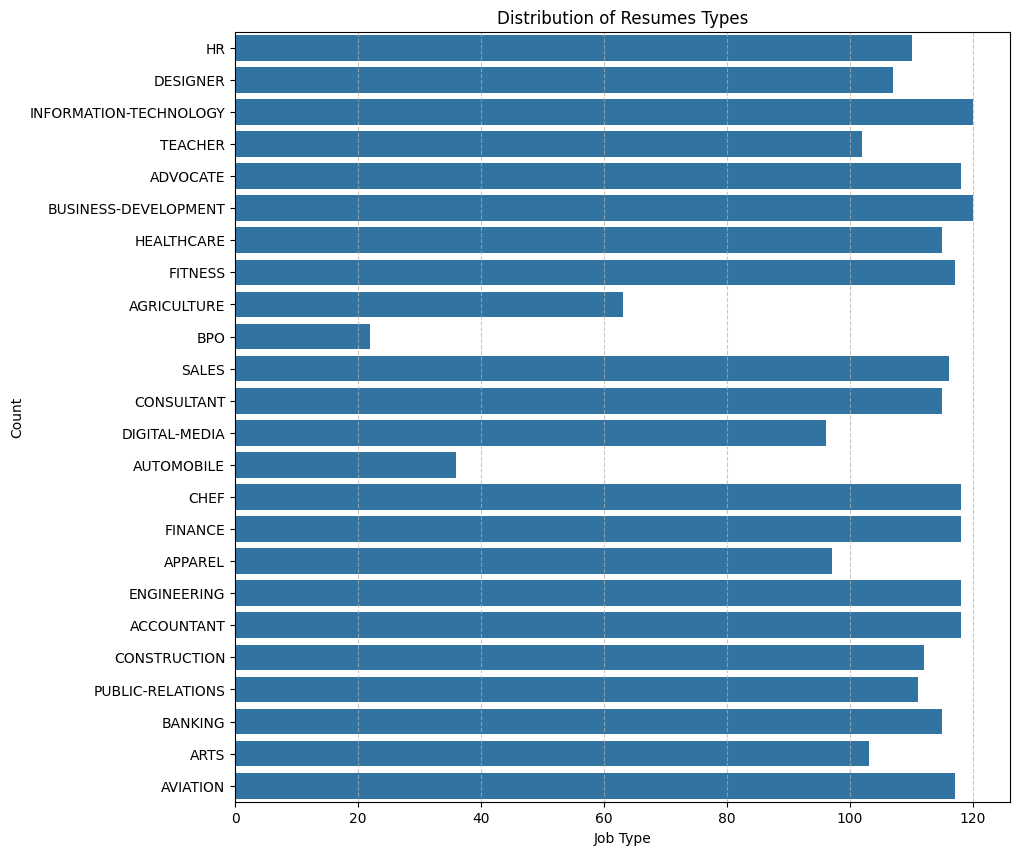

In [3]:
plt.figure(figsize=(10,10))
sns.countplot(data=resume_table, y='Category')
plt.title('Distribution of Resumes Types')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Data Processing

The resumes are separated into their respective category folders i.e. `ACCOUNTANT`, `CONSTRUCTION`, `CHEF`, etc. To streamline the data processing and model training, we will move them into a single folder. We can reference their categories using `resume_table`.

In [4]:
main_dir = Path("data/resumes/")
output_fp = Path("data/all_resumes/")
output_fp.mkdir(parents=True, exist_ok=True)

def flatten_resumes():
    for cat in main_dir.rglob("*.pdf"):
        dest = output_fp / cat.name
        shutil.copy(cat, dest)

# Run once
# flatten_resumes()
all_resumes_fp = "data/all_resumes"

### Extract Text from PDF
The data is stored as PDFs of each resume, so we cannot directly used the files in our model. We will use the `fitz` module to parse and extract the text from the PDF files.

In [5]:
def extract_text(fp):
    document = fitz.open(fp)
    raw_text = "".join(i.get_text() for i in document)
    return re.sub(r'\s+', ' ', raw_text.replace('\n', ' ')).strip()

Below we will look at a random example of the text contain in a resume.

In [6]:
pdf_fps = [i for i in os.listdir(all_resumes_fp)]

idx = random.randint(0, len(pdf_fps)-1)
resume_file = os.path.join(all_resumes_fp, pdf_fps[idx])

extract_text(resume_file)

"PERSONAL TRAINER Summary Hard working, seasoned customer service professional with extensive experience in face to face service and sales, seeking a new opportunity in a stable organization where I can use my skills and knowledge to make a positive contribution and assist in the growth of both the company and my personal career. Highly motivated professional with excellent interpersonal and motivational skills Infectious enthusiasm and positive attitude Extensive experience meeting goals; both personal and professional (i.e., sales, fees, gross profit, contribution, and hours) Experience and successful track record of managing others Proven experience in sales: over $150,00 dollars sold in 3 years Building and maintaining relationships with key customers and business leaders in the community Experience gained in leading staff in business development, customer retention, recruiting, and expense management Self-motivated individual continuously striving for success Strong sense of disci

### Build Dataset Class and Dataloader

In [7]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Run this once
# df = pd.DataFrame(resume_table[["ID", "Category"]])
# df["text"] =  df["ID"].apply(lambda f: extract_text(os.path.join(all_resumes_fp ,f"{f}.pdf")))

# Save df
# df.to_csv("resume_data.csv", index=False)

# Load df from saved file
df = pd.read_csv("resume_data.csv")
df = df.dropna(subset=["text"]).reset_index(drop=True)

holdout = df.sample(n=100, random_state=42)
df = df.drop(holdout.index)

holdout = holdout.reset_index(drop=True)
df = df.reset_index(drop=True)
df

,ID,Category,text
0,16852973,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE HR ADMINI...
1,22323967,HR,"HR SPECIALIST, US HR OPERATIONS Summary Versat..."
2,33176873,HR,HR DIRECTOR Summary Over 20 years experience i...
3,27018550,HR,"HR SPECIALIST Summary Dedicated, Driven, and D..."
4,17812897,HR,HR MANAGER Skill Highlights HR SKILLS HR Depar...
...,...,...,...
2378,99416532,AVIATION,RANK: SGT/E-5 NON- COMMISSIONED OFFICER IN CHA...
2379,24589765,AVIATION,"GOVERNMENT RELATIONS, COMMUNICATIONS AND ORGAN..."
2380,31605080,AVIATION,GEEK SQUAD AGENT Professional Profile IT suppo...
2381,21190805,AVIATION,PROGRAM DIRECTOR / OFFICE MANAGER Summary High...


```
def preprocess(text):
    return re.sub(r'\s+', ' ', raw_text.replace('\n', ' ')).strip()
    
class ResumeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512, mode="train"):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def get_tokens(self, text, max_len):
        text = preprocess(text)
        tokens = self.tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=max_len)
        pad_length = max_len - len(tokens)
        if pad_length > 0:
            tokens += [self.tokenizer.pad_token_id] * pad_length
        mask = [1] * len(tokens[:max_len]) + [0] * pad_length
        mask = mask[:max_len]
        return tokens[:max_len], mask

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens, mask = self.get_tokens(self.texts[idx], self.max_len)
        input_ids = torch.tensor(tokens, dtype=torch.long)
        attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        seq_len = (attention_mask == 1).sum().item()

        if self.mode == "train":
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return {"input_ids": input_ids,
                    "mask": mask,
                    "seq_len": seq_len,
                    "labels": label}

        return {"input_ids": input_ids,
                "mask": mask,
                "seq_len": seq_len}
```

### Model Architecure
We will define a model architecture based on a pre-trained `BERT` model. The model will be a multi-class classifier (job category).

In [8]:
class BERTClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.BERT = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.25)
        self.classifier = nn.Linear(self.BERT.config.hidden_size, num_classes)

    def forward(self, input_ids, mask):
        output = self.BERT(input_ids, mask)
        x = self.dropout(output.last_hidden_state[:, 0, :])
        return self.classifier(x)

In [9]:
# Model parameters
BATCH_SIZE = 16
EPOCHS = 10
MAX_LEN = 256

The custom `Dataset` class may cause an `AttributeError` when called in a Jupyter Notebook. To resolve this, it is recommended to save the class (along with any dependencies) in a separate `.py` file and import the class. The code is provided above in markdown format for transparency. The same code is found in the `resume_dataset.py` module.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

train_losses = []
val_losses = []
val_acc = []

def train_model(train_losses, val_losses, val_acc):
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(df["Category"])

    X_train, X_val, y_train, y_val = train_test_split(df["text"], labels, stratify=labels, test_size=0.2)
    train_dataset = ResumeDataset(tokenizer, X_train.tolist(), y_train.tolist(), max_len=MAX_LEN)
    val_dataset = ResumeDataset(tokenizer, X_val.tolist(), y_val.tolist())
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    model = BERTClassifier(num_classes=len(label_encoder.classes_))
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=2e-5)
    cross_entropy_loss = CrossEntropyLoss()

    # Train loop
    for epoch in range(EPOCHS):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(device)
            mask = batch["mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, mask=mask)
            loss = cross_entropy_loss(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {total_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0 
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                mask = batch["mask"].to(device)
                labels = batch["labels"].to(device)
                logits = model(input_ids=input_ids, mask=mask)
                loss = cross_entropy_loss(logits, labels)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        acc = correct / total
        val_losses.append(val_loss)
        val_acc.append(acc)
        print(f"Epoch {epoch + 1}, Val Loss: {val_loss:.4f}, Val Acc: {acc:.4f}")
        model.train()

        # Release memory
        torch.cuda.empty_cache()
        gc.collect()

    torch.save(model.state_dict(), "models/BERT_MODEL_0.pt")

    return model, label_encoder, labels

Device: cuda


In [11]:
model, label_encoder, labels = train_model(train_losses, val_losses, val_acc)

Training Epoch 1: 100%|██████████████████████████████████████████████████████████████| 120/120 [00:46<00:00,  2.57it/s]


Epoch 1, Train Loss: 273.3686
Epoch 1, Val Loss: 31.9789, Val Acc: 0.7547


Training Epoch 2: 100%|██████████████████████████████████████████████████████████████| 120/120 [00:46<00:00,  2.56it/s]


Epoch 2, Train Loss: 107.7467
Epoch 2, Val Loss: 21.7602, Val Acc: 0.8197


Training Epoch 3: 100%|██████████████████████████████████████████████████████████████| 120/120 [00:46<00:00,  2.57it/s]


...

Epoch 8, Train Loss: 13.8696
Epoch 8, Val Loss: 21.9277, Val Acc: 0.8491


Training Epoch 9: 100%|██████████████████████████████████████████████████████████████| 120/120 [00:45<00:00,  2.64it/s]


Epoch 9, Train Loss: 10.5814
Epoch 9, Val Loss: 21.8303, Val Acc: 0.8512


Training Epoch 10: 100%|█████████████████████████████████████████████████████████████| 120/120 [00:46<00:00,  2.60it/s]


Epoch 10, Train Loss: 7.3077
Epoch 10, Val Loss: 23.2222, Val Acc: 0.8512


The model appears to work well despite some of the constraints placed on it. Specifically, while `BERT` accepts a maximum of 512 tokens, the model was train on data restricted to 256 tokens to expedite the training process (more tokens takes up more memory). The model is able to achieve >80% validation accuracy in just 10 epochs, and it is likely that the important features (resume information) can be learned from the first 256 tokens. Resumes tend to contain the education information or personal statements at the top of the page, which are usually significant to the type of job. This may not always be the case, but the decisions made for the dataset preparation and model training were to balance model performance and compute time.

In [11]:
# # Metrics
# metrics_df = pd.DataFrame({
#     "Epoch": list(range(1, EPOCHS+1)),
#     "Train Loss": train_losses,
#     "Val Loss": val_losses,
#     "Val Accuracy": val_acc
# })

# metrics_df.to_csv("training_metrics.csv", index=False)

# # Save label encoder
# np.save("label_classes.npy", label_encoder.classes_)

label_encoder = LabelEncoder()
label_encoder.classes_ = np.load("label_classes.npy", allow_pickle=True)

### Training and Validtion Metrics

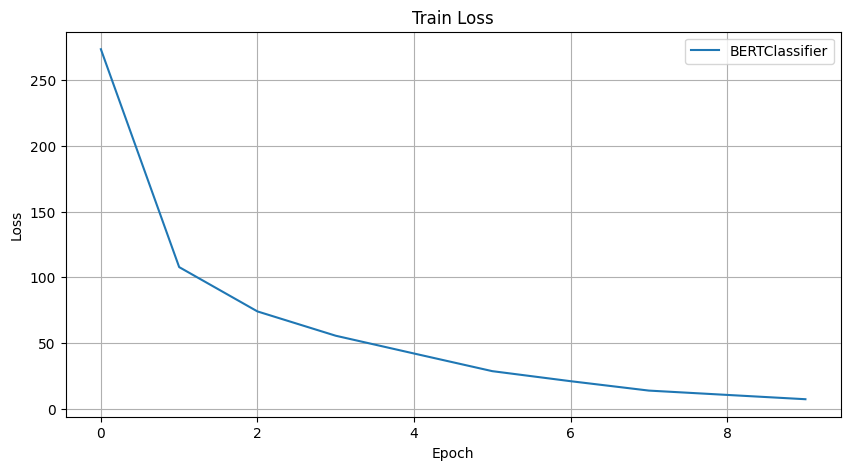

In [12]:
metrics = pd.read_csv("training_metrics.csv")
plt.figure(figsize=(10, 5))
plt.plot(metrics['Train Loss'], label="BERTClassifier")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss")
plt.legend()
plt.grid(True)
plt.show()

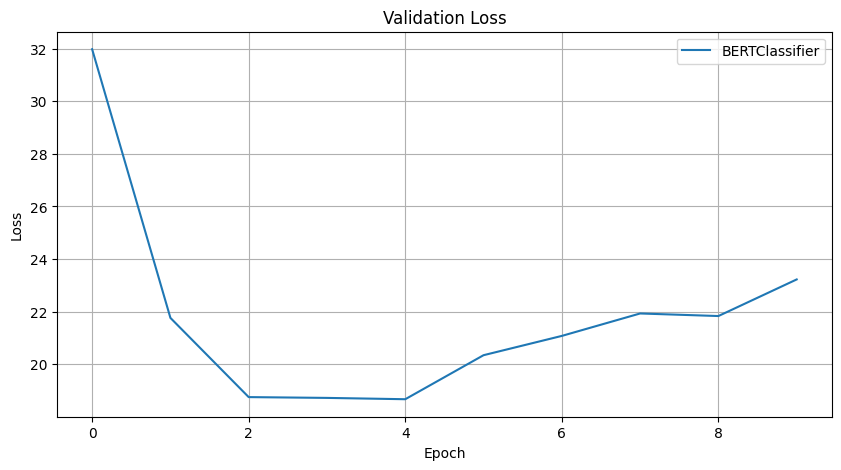

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(metrics['Val Loss'], label="BERTClassifier")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

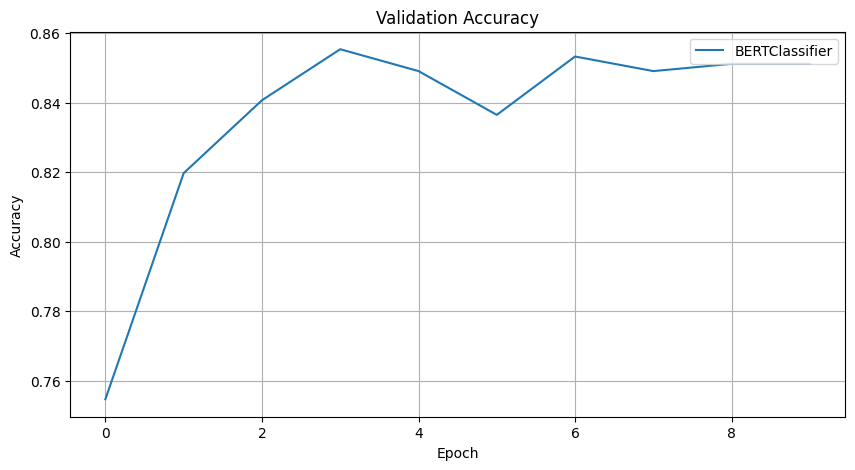

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(metrics['Val Accuracy'], label="BERTClassifier")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Inference
The dataset did not include a specific data sample for inference nor did it have a submission with hidden test examples. To perform inference, we selected a holdout set of 100 examples from the data that is not used in training or validation.

In [15]:
# Load model
model = BERTClassifier(num_classes=len(np.unique(df["Category"].values)))
model.load_state_dict(torch.load("models/BERT_MODEL_0.pt"))
model.to(device)
model.eval()

BERTClassifier(
  (BERT): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [16]:
holdout_dataset = ResumeDataset(tokenizer, holdout["text"].tolist(), labels=None, mode="test")
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE)

In [17]:
predictions = []

with torch.no_grad():
    for batch in holdout_loader:
        input_ids = batch["input_ids"].to(device)
        mask = batch["mask"].to(device)
        logits = model(input_ids=input_ids, mask=mask)
        preds = torch.argmax(logits, dim=1)
        predictions.extend(preds.cpu().tolist())

predictions = label_encoder.inverse_transform(predictions)
holdout["predictions"] = predictions
holdout

,ID,Category,text,predictions
0,23573064,FINANCE,PROGRAMME FINANCE ASSOCIATE Professional Summa...,FINANCE
1,17562754,DIGITAL-MEDIA,DIRECTOR OF DIGITAL TRANSFORMATION Executive P...,DIGITAL-MEDIA
2,38087844,SALES,TIMESHARE SALES Summary I am extremely confide...,SALES
3,19007667,CHEF,CHEF Summary Experienced catering chef skilled...,CHEF
4,93576192,ARTS,ENGLISH LANGUAGE ARTS TEACHER Summary Experien...,ARTS
...,...,...,...,...
95,29211919,SALES,SALES ASSOCIATE Summary Courteous and dependab...,SALES
96,23818675,CONSTRUCTION,CAD/GIS DESIGN SPECIALIST Summary A diverse Co...,CONSTRUCTION
97,13294301,ACCOUNTANT,ACCOUNTANT Professional Summary Emerging accou...,ACCOUNTANT
98,36136569,APPAREL,SR. PROJECT MANAGEMENT ASSOCIATE Professional ...,APPAREL


### Prediction Score

In [18]:
ground_truth = holdout["Category"]
pred = holdout["predictions"]
print(f"Accuracy Score: {accuracy_score(ground_truth, pred)}")

Accuracy Score: 0.81


The model appears to perform similarly on the holdout set, with an accuracy score of `0.81` on unseen examples.

## Generate Resume Summaries
The large volume of resumes that are received for even a single job opening makes it difficult to sustainably and fairly evaluate each candidates' qualifications. Our NLP model can tell us the job category a resume is appropriate for, but it does not give insights into the candidate's experience or fit with a role. We propose a second model used in tandem with the `BERTClassifier`: a language model that summarizes a resumes to provide a concise evaluation of an applicant. While this approach will not necessarily substitute a fair/full evaluation of a candidate, it can serve as a sustainable method to determine the most appropriate resumes/candidates to focus on.

For fast training and simpler architecture, we will using HuggingFace's `datasets` and `transformers` libraries. We will be fine-tuning a `T5` encoder-decoder transformer model.

In [59]:
dataset = Dataset.from_pandas(df[["text", "Category"]])

model_name = "google/flan-t5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

In [63]:
MAX_LEN = 256
TARGET_LEN = 64
EPOCHS = 10
BATCH_SIZE = 8
LR = 2e-5
output_fp = "models/t5_resume_summarizer"

In [71]:
def preprocess(examples):
    inputs = ["Summarize: " + text for text in examples["text"]]
    model_inputs = tokenizer(inputs, truncation=True, max_length=MAX_LEN, padding="max_length")

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(examples["Category"], truncation=True, max_length=TARGET_LEN, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [72]:
tokenized_dataset = dataset.map(preprocess, batched=True, remove_columns=dataset.column_names)
training_args = TrainingArguments(
    output_dir=output_fp,
    per_device_train_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    save_strategy="epoch",
    logging_steps=100,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset
)

Map:   0%|          | 0/2383 [00:00<?, ? examples/s]

C:\Users\ericy\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [73]:
trainer.train()
trainer.save_model("models/t5_resume_summarizer")

Step,Training Loss
100,0.000000
200,0.000000
300,0.000000
400,0.000000
500,0.000000
600,0.000000
700,0.000000
800,0.000000
900,0.000000
1000,0.000000


In [75]:
tokenizer = T5Tokenizer.from_pretrained(output_fp)
model = T5ForConditionalGeneration.from_pretrained(output_fp)
model = model.to(device)
model.eval()

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [76]:
test_df = holdout.sample(10)

In [77]:
def generate_summary(text, max_input=256, max_output=64):
    input_text = "Summarize: " + text.strip().replace("\n", " ")
    input_ids = tokenizer.encode(input_text, return_tensors="pt", truncation=True, max_length=max_input).to(device)
    summary_ids = model.generate(input_ids, max_length=max_output, min_length=20, do_sample=False)
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

summaries = []
for text in tqdm(test_df["text"], desc="Generating summaries"):
    summaries.append(generate_summary(text))

test_df["generated_summary"] = summaries

Generating summaries: 100%|████████████████████████████████████████████████████████████| 10/10 [00:09<00:00,  1.10it/s]


In [78]:
test_df

,ID,Category,text,predictions,generated_summary
83,31273413,ARTS,ARTS EDUCATOR Summary Creative and innovative ...,ARTS,"Florida. Educated children in art, science, an..."
53,19243556,FINANCE,"DIRECTOR OF FINANCE Executive Profile Dynamic,...",FINANCE,FINANCIAL DIRECTOR - Executive Profile Dynamic...
70,21904897,CHEF,CHEF Summary I have been in the restaurant bus...,CHEF,
45,29897742,AGRICULTURE,ADULT EDUCATION TEACHER Accomplishments Cal Po...,TEACHER,- ADULT EDUCATION TEACHER Accomplishments Cal ...
44,39970711,HR,HR & SAFETY MANAGER Summary Human Resources Ma...,HR,Summary: Human Resources Manager Certified Pro...
39,21611637,CHEF,STORE CHEF Summary Restaurant Professional Exe...,CHEF,Chef /Sous Chef /Chef Manager Position Propone...
22,18460045,DESIGNER,FREELANCE GRAPHIC DESIGNER Highlights Summary:...,DESIGNER,Licensed in the United States. Known for her w...
80,20141807,SALES,SALES ASSOCIATE Summary I have been with IBC f...,SALES,- APPLY FOR AN APPLICATION TO APPLY FOR A POSI...
10,32219038,HEALTHCARE,ENUMERATOR Summary Recent graduate with BA in ...,ADVOCATE,- Interested in a career as an Administrative ...
0,23573064,FINANCE,PROGRAMME FINANCE ASSOCIATE Professional Summa...,FINANCE,


In [79]:
sample_resume = test_df.iloc[0]
print(f"Resume ID: {sample_resume["ID"]}")
print(f"Job Category: {sample_resume["predictions"]}")
print(f"Summary: {sample_resume["generated_summary"]}")

Resume ID: 31273413
Job Category: ARTS
Summary: Florida. Educated children in art, science, and math. Developed a strong relationship with students.


In [80]:
sample_resume = test_df.iloc[1]
print(f"Resume ID: {sample_resume["ID"]}")
print(f"Job Category: {sample_resume["predictions"]}")
print(f"Summary: {sample_resume["generated_summary"]}")

Resume ID: 19243556
Job Category: FINANCE
Summary: FINANCIAL DIRECTOR - Executive Profile Dynamic, results-oriented Controller with over 25 years experience, demonstrating expertise in financial reporting and analysis. Strong track record in creating and implementing internal controls, to reduce the risk of fraud, exposure and loss. Created SOD to increase efficiency and


In [81]:
sample_resume = test_df.iloc[2]
print(f"Resume ID: {sample_resume["ID"]}")
print(f"Job Category: {sample_resume["predictions"]}")
print(f"Summary: {sample_resume["generated_summary"]}")

Resume ID: 21904897
Job Category: CHEF
Summary: 


In [82]:
sample_resume = test_df.iloc[3]
print(f"Resume ID: {sample_resume["ID"]}")
print(f"Job Category: {sample_resume["predictions"]}")
print(f"Summary: {sample_resume["generated_summary"]}")

Resume ID: 29897742
Job Category: TEACHER
Summary: - ADULT EDUCATION TEACHER Accomplishments Cal Poly Pomona Pomona, CA, USA Community Involvement Been a leader with High Desert Challengers 4Hfor the last 12 years. Have been involved with helping the kids raise animals to


In [83]:
sample_resume = test_df.iloc[4]
print(f"Resume ID: {sample_resume["ID"]}")
print(f"Job Category: {sample_resume["predictions"]}")
print(f"Summary: {sample_resume["generated_summary"]}")

Resume ID: 39970711
Job Category: HR
Summary: Summary: Human Resources Manager Certified Professional in Human Resources (PHR) Extensive background in human resources management, including experience in workforce planning and employment, human resource development, compensation and benefits, risk management, employee and labor relations, HR technology, global and international HR, talent management, and change management.


## Conclusion
This project gave me some insights on how the hiring process and how AI may have a significant role in selecting candidates in companies that use it. Using deep learning / NLP models to sort resumes into the appropriate categories appears to be a well defined problem and does not appear to be very difficult to train a model on. I think a more interesting idea would be to build a model that selectively places resumes in specific levels of a role. For example, a software engineer resume could be categorized by years of experience and specialization, which would be mapped to the company's database on current available positions. Generating summaries for resumes appears to be much less non-trivial, as resumes may vary in format (especially across industries). I do believe that AI models are presently capable enough to play a role in separating candidates into appropriate job positions, but they likely are not yet able to fairly evaluate a candidate without external context such as company mission or specifics to a role.

# References
* https://pytorch.org/
* https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
* https://neptune.ai/blog/how-to-code-bert-using-pytorch-tutorial
* https://huggingface.co/docs/transformers/en/model_doc/bert
* https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset
* https://huggingface.co/docs/transformers/en/model_doc/t5
* https://huggingface.co/docs/transformers/en/main_classes/trainer